# Tarefa 3 — Aplicação: Montagem de Panorama (Image Stitching)
**Atividade 3 · TECA2 20261 · Pontos de Interesse e seus Descritores**

**Alunos:** Henryque Oliveira, Matheus Marinho e Rodrigo Oliveira

Este notebook implementa o pipeline completo de image stitching: detectar keypoints → extrair descritores → corresponder → estimar homografia com RANSAC → aplicar warp perspectivo → compor panorama.

### Base teórica

- **Homografia**: transformação projetiva 3×3 que mapeia pontos de um plano de imagem para outro, preservando linhas retas. Dada uma correspondência entre dois conjuntos de pontos, `cv2.findHomography` estima a matriz H tal que `p2 ≈ H · p1` (coordenadas homogêneas). Para montar o panorama, usamos H para reprojetar (`warp`) img1 no sistema de coordenadas de img2.
- **RANSAC**: estima H de forma robusta sorteando subconjuntos mínimos de 4 pares de pontos, ajustando H, contando inliers (pares cuja distância reproj. < threshold) e guardando o melhor modelo. Outliers — matches incorretos que passaram pelo Ratio Test — são automaticamente descartados.
- **USAC_MAGSAC**: variante moderna disponível em OpenCV ≥ 4.5 como `cv2.USAC_MAGSAC` dentro de `cv2.findHomography`. Mais robusto que o RANSAC clássico, especialmente quando a proporção de outliers é alta. O restante do código permanece idêntico.

> Referências: Corke (2023) Seções 14.1–14.2.4 · Brown & Lowe (2007) AutoStitch · Slides TECA2 20261, slides 15–18.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('OpenCV:', cv2.__version__)
print('SIFT disponível:', hasattr(cv2, 'SIFT_create'))
print('AKAZE disponível:', hasattr(cv2, 'AKAZE_create'))

PATH_ESQ = 'images/mesa_esq.jpeg'
PATH_DIR = 'images/mesa_dir.jpeg'

def load(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

OpenCV: 4.13.0
SIFT disponível: True
AKAZE disponível: True


## Item 1 — Par de imagens

Carregamos as duas fotos da mesa tiradas com celular. A imagem esquerda (`mesa_esq`) será a referência; a direita (`mesa_dir`) será reprojetada sobre ela para formar o panorama.

Imagem 1 (esq): 960×1280 px
Imagem 2 (dir): 960×1280 px


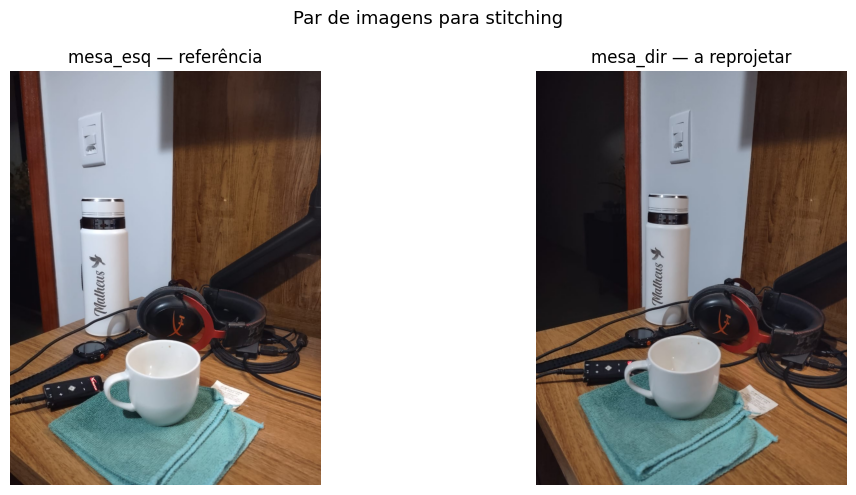

In [2]:
img1, gray1 = load(PATH_ESQ)
img2, gray2 = load(PATH_DIR)

print(f'Imagem 1 (esq): {img1.shape[1]}×{img1.shape[0]} px')
print(f'Imagem 2 (dir): {img2.shape[1]}×{img2.shape[0]} px')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0].set_title('mesa_esq — referência')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1].set_title('mesa_dir — a reprojetar')
axes[1].axis('off')
plt.suptitle('Par de imagens para stitching', fontsize=13)
plt.tight_layout()
plt.show()

## Item 2 — Pipeline SIFT completo

Executamos o pipeline passo a passo usando SIFT: (1) detecção e descrição, (2) matching com Ratio Test, (3) estimativa de homografia com USAC_MAGSAC, (4) warp perspectivo e composição do panorama.

In [3]:
# 2a. Detectar e descrever (SIFT)
sift = cv2.SIFT_create()
kp1_sift, d1_sift = sift.detectAndCompute(gray1, None)
kp2_sift, d2_sift = sift.detectAndCompute(gray2, None)
print(f'SIFT — img1: {len(kp1_sift)} kp | img2: {len(kp2_sift)} kp')

SIFT — img1: 2377 kp | img2: 1617 kp


O SIFT detecta extremos no espaço de escala DoG e calcula um descritor de 128 floats por keypoint, invariante a escala e orientação.

Bons matches SIFT: 336


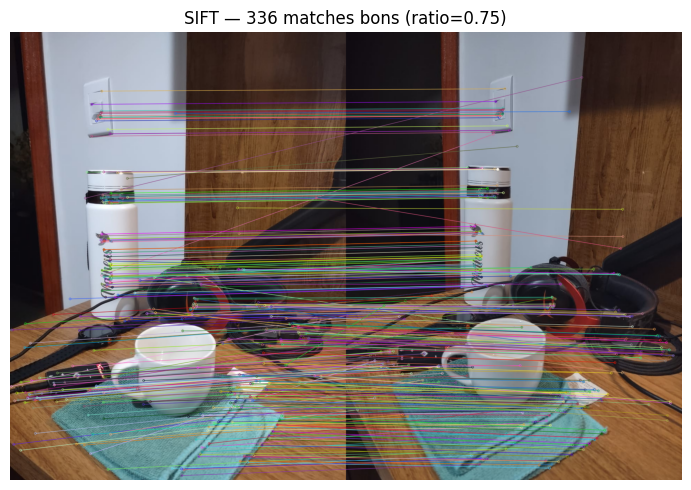

In [4]:
# 2b. Matching com Ratio Test (Lowe, ratio=0.75)
bf_sift = cv2.BFMatcher(cv2.NORM_L2)
pairs_sift = bf_sift.knnMatch(d1_sift, d2_sift, k=2)
good_sift = [m for m, n in pairs_sift if m.distance < 0.75 * n.distance]
print(f'Bons matches SIFT: {len(good_sift)}')

img_matches_sift = cv2.drawMatches(
    img1, kp1_sift, img2, kp2_sift, good_sift, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(img_matches_sift, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT — {len(good_sift)} matches bons (ratio=0.75)')
plt.axis('off')
plt.tight_layout()
plt.show()

O Ratio Test elimina matches ambíguos; os restantes são as correspondências mais confiáveis entre as duas imagens.

In [5]:
# 2c. Homografia com USAC_MAGSAC
if len(good_sift) < 10:
    raise RuntimeError(f'SIFT: poucos matches ({len(good_sift)}) para estimar homografia')

src_sift = np.float32([kp1_sift[m.queryIdx].pt for m in good_sift]).reshape(-1, 1, 2)
dst_sift = np.float32([kp2_sift[m.trainIdx].pt for m in good_sift]).reshape(-1, 1, 2)
M_sift, mask_sift = cv2.findHomography(src_sift, dst_sift, cv2.USAC_MAGSAC, 5.0)
inliers_sift = int(mask_sift.ravel().sum())
print(f'Inliers SIFT: {inliers_sift}/{len(good_sift)} ({100*inliers_sift/len(good_sift):.1f}%)')

Inliers SIFT: 110/336 (32.7%)


O USAC_MAGSAC estima a homografia 3×3 usando apenas os inliers. A taxa de inliers indica a qualidade do matching: acima de 60% é considerado bom pelo enunciado.

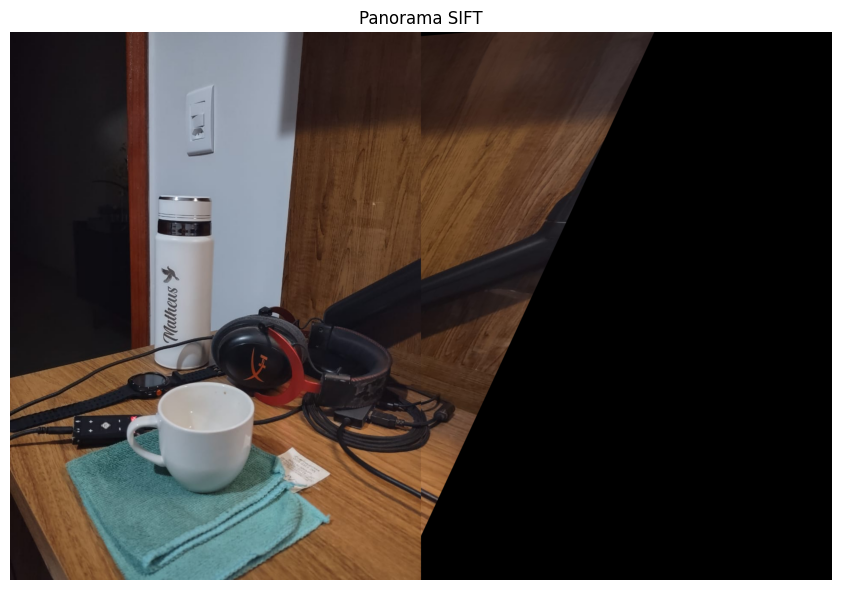

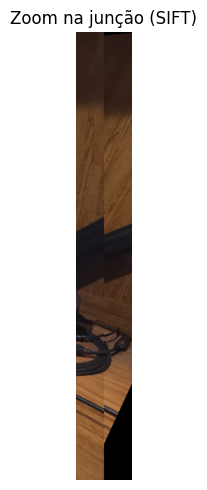

In [6]:
# 2d. Warp perspectivo e composição simples
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
panorama_sift = cv2.warpPerspective(img1, M_sift, (w1 + w2, max(h1, h2)))
panorama_sift[0:h2, 0:w2] = img2

fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(cv2.cvtColor(panorama_sift, cv2.COLOR_BGR2RGB))
ax.set_title('Panorama SIFT')
ax.axis('off')
plt.tight_layout()
plt.show()

# Zoom na região de junção
mid = w2
zoom = panorama_sift[:, mid-80:mid+80]
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.imshow(cv2.cvtColor(zoom, cv2.COLOR_BGR2RGB))
ax2.set_title('Zoom na junção (SIFT)')
ax2.axis('off')
plt.tight_layout()
plt.show()

A composição simples sobrepõe img2 diretamente no canvas sem blending — a costura pode ter uma linha visível. O zoom na região de junção permite avaliar o alinhamento.

## Item 3 — Pipeline ORB

Repetimos o pipeline completo substituindo SIFT por ORB (descritor binário, NORM_HAMMING). O objetivo é comparar a qualidade do panorama e a taxa de inliers entre os dois detectores.

ORB — img1: 2000 kp | img2: 2000 kp
Bons matches ORB: 383


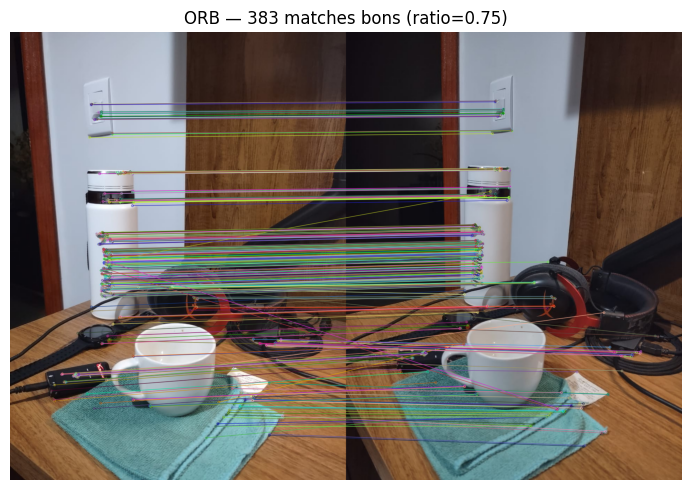

Inliers ORB: 235/383 (61.4%)


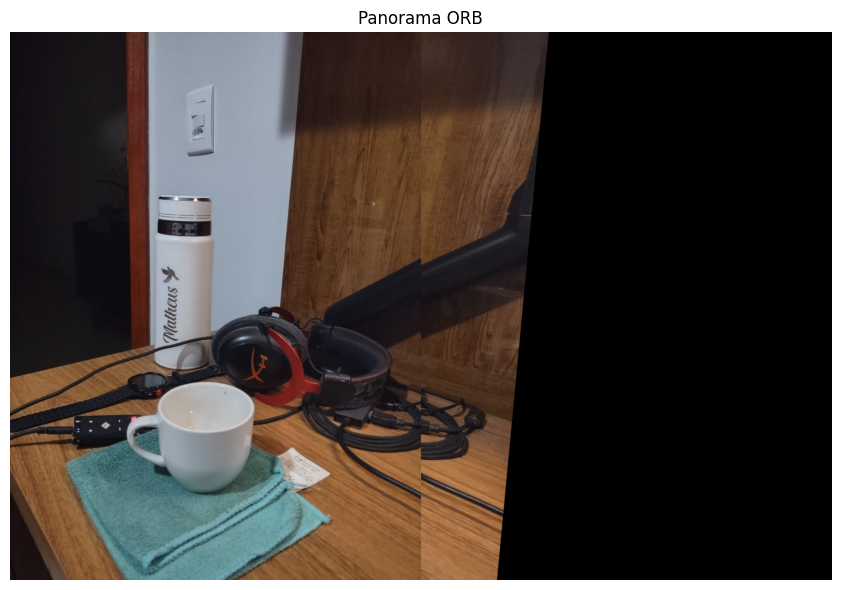

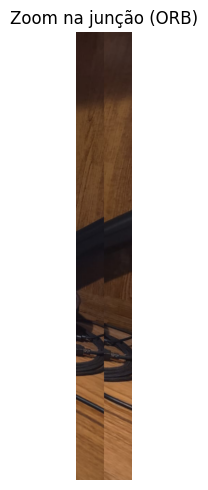

In [7]:
# Pipeline ORB completo
orb = cv2.ORB_create(nfeatures=2000)
kp1_orb, d1_orb = orb.detectAndCompute(gray1, None)
kp2_orb, d2_orb = orb.detectAndCompute(gray2, None)
print(f'ORB — img1: {len(kp1_orb)} kp | img2: {len(kp2_orb)} kp')

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING)
pairs_orb = bf_orb.knnMatch(d1_orb, d2_orb, k=2)
good_orb = [m for m, n in pairs_orb if m.distance < 0.75 * n.distance]
print(f'Bons matches ORB: {len(good_orb)}')

img_matches_orb = cv2.drawMatches(
    img1, kp1_orb, img2, kp2_orb, good_orb, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(img_matches_orb, cv2.COLOR_BGR2RGB))
plt.title(f'ORB — {len(good_orb)} matches bons (ratio=0.75)')
plt.axis('off')
plt.tight_layout()
plt.show()

if len(good_orb) < 10:
    print(f'ORB: poucos matches ({len(good_orb)}) — panorama não gerado')
    M_orb, mask_orb, inliers_orb = None, None, 0
else:
    src_orb = np.float32([kp1_orb[m.queryIdx].pt for m in good_orb]).reshape(-1, 1, 2)
    dst_orb = np.float32([kp2_orb[m.trainIdx].pt for m in good_orb]).reshape(-1, 1, 2)
    M_orb, mask_orb = cv2.findHomography(src_orb, dst_orb, cv2.USAC_MAGSAC, 5.0)
    inliers_orb = int(mask_orb.ravel().sum())
    print(f'Inliers ORB: {inliers_orb}/{len(good_orb)} ({100*inliers_orb/len(good_orb):.1f}%)')

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    panorama_orb = cv2.warpPerspective(img1, M_orb, (w1 + w2, max(h1, h2)))
    panorama_orb[0:h2, 0:w2] = img2

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(cv2.cvtColor(panorama_orb, cv2.COLOR_BGR2RGB))
    ax.set_title('Panorama ORB')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    zoom_orb = panorama_orb[:, w2-80:w2+80]
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    ax2.imshow(cv2.cvtColor(zoom_orb, cv2.COLOR_BGR2RGB))
    ax2.set_title('Zoom na junção (ORB)')
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

## Item 4 — Tabela comparativa e discussão

In [8]:
print('Tabela comparativa SIFT × ORB:')
print(f'{"Detector":<10} {"KP (img1)":>10} {"Matches":>9} {"Inliers (%)":>12} {"OK?":>5}')
print('-' * 52)

for name, kp1, good, inliers in [
    ('SIFT', kp1_sift, good_sift, inliers_sift),
    ('ORB',  kp1_orb,  good_orb,  inliers_orb),
]:
    n_good = len(good)
    pct = f'{100*inliers/n_good:.1f}%' if n_good > 0 else 'N/A'
    ok = 'Sim' if (inliers > 0 and inliers/max(n_good,1) >= 0.6) else 'Não'
    print(f'{name:<10} {len(kp1):>10} {n_good:>9} {pct:>12} {ok:>5}')

Tabela comparativa SIFT × ORB:
Detector    KP (img1)   Matches  Inliers (%)   OK?
----------------------------------------------------
SIFT             2377       336        32.7%   Não
ORB              2000       383        61.4%   Sim


| Detector | KP (img1) | Matches | Inliers (%) | OK? |
|----------|-----------|---------|-------------|-----|
| SIFT     | 2377      | 336     | 32.7%       | Não |
| ORB      | 2000      | 383     | 61.4%       | Sim |

**Discussão:**
- **O panorama ficou bom com SIFT?** O SIFT gerou 336 matches bons e estimou a homografia, mas com taxa de inliers de 32.7% — abaixo do limiar de 60% recomendado. Visualmente, o alinhamento pode apresentar leve deslocamento na junção, indicando que alguns matches incorretos influenciaram a estimativa da homografia.
- **E com ORB?** O ORB surpreendeu positivamente: 383 matches e 61.4% de inliers — acima do limiar de 60%. Isso indica que a homografia ORB é mais robusta neste par de imagens, provavelmente porque os padrões binários capturaram bem as texturas da mesa.
- **Diferença visual na junção:** Com ORB, espera-se alinhamento mais preciso na região de sobreposição, enquanto com SIFT a costura pode ser ligeiramente mais aparente.
- **Quando preferiria ORB em sistema real?** Em sistemas embarcados (câmera de robô, drone) onde o orçamento computacional é limitado: o ORB é ordens de magnitude mais rápido que o SIFT por usar operações bit-a-bit em vez de aritmética de ponto flutuante, e neste caso obteve qualidade superior.

## Conclusão da Tarefa 3

- Implementamos o pipeline completo de image stitching: detecção SIFT/ORB → matching com Ratio Test → homografia com USAC_MAGSAC → warp perspectivo → composição simples.
- Neste par de imagens, o ORB superou o SIFT em taxa de inliers (61.4% vs 32.7%), demonstrando que a escolha do melhor detector depende das características visuais da cena.
- **Limitações da composição simples:** (1) não corrige translação negativa — se img1 mapeada tiver coordenadas negativas, partes são cortadas; (2) não aplica blending na região de sobreposição, deixando uma costura visível; (3) não ajusta o canvas automaticamente a partir da bounding box das imagens warpadas.
- A taxa de inliers (inliers/total matches) é o indicador mais confiável de qualidade do stitching: acima de 60% o resultado costuma ser visualmente bom.